In [76]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [77]:
# Note: 'slip_dataset_all.pkl' require pandas version >= 2.1.4 (python >= 3.10)
dataset = 'tests/test_data/dataframe_test_data/marmotte/ga_hard_snow_25_01_a/slip_dataset_all.pkl'
root = os.path.join(os.getcwd(), '..')
data_path = os.path.realpath(os.path.join(root, dataset))
print(f"Using saved Panda dataframe: {data_path}")
print(f"Saved Panda dataframe exists: {os.path.exists(data_path)}")
dataset_snow = pd.read_pickle(data_path)

Using saved Panda dataframe: /ros2_ws/src/trajectory-container-tools/tests/test_data/dataframe_test_data/marmotte/ga_hard_snow_25_01_a/slip_dataset_all.pkl
Saved Panda dataframe exists: True


### Requirement:
The dataframe must contain one trajectory or a batch of trajectories (one per row) with some features (column) containing a timestep index in there name e.g., `feature_1`, `feature_2` ...

In [78]:
dataset_snow.head()

,init_icp_x,init_icp_y,init_icp_z,init_icp_roll,init_icp_pitch,init_icp_yaw,calib_step,cmd_left_0,cmd_right_0,cmd_left_1,...,body_vel_disturption_yaw_30,body_vel_disturption_yaw_31,body_vel_disturption_yaw_32,body_vel_disturption_yaw_33,body_vel_disturption_yaw_34,body_vel_disturption_yaw_35,body_vel_disturption_yaw_36,body_vel_disturption_yaw_37,body_vel_disturption_yaw_38,body_vel_disturption_yaw_39
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,6.337527,...,0.001605,0.006716,0.017343,0.025290,0.024934,0.020090,0.017515,0.016509,0.017604,0.017604
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.337527,6.558533,6.337527,...,-0.003664,-0.004462,-0.004982,-0.005214,-0.005224,-0.005149,-0.005063,-0.004978,-0.004937,-0.004937
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.337527,6.558533,6.337527,...,0.035404,0.024445,0.005511,-0.011774,-0.021206,-0.026605,-0.019148,-0.010976,-0.002586,-0.002586
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-5.933710,5.305197,-5.933710,...,-0.436207,-0.427349,-0.408820,-0.387365,-0.358591,-0.331346,-0.303292,-0.283153,-0.267858,-0.266377
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-5.933710,5.305197,-5.933710,...,1.415197,1.747023,1.787952,1.410041,0.570877,-0.600815,-1.782877,-2.689737,-2.858565,-2.858565


# Using _trajectory-container-tools_ with Panda `DataFrame`

```python
def aggregate_multiple_features_from_dataframe(
        dataset_frame: pd.DataFrame,
        dataset_info: str,
        features_config: dict[str, Union[Type[AbstractFeatureDataclass], tuple[str, ...]]]
    ) -> dataclass:
    ...
```

- param `dataset_frame`: Dataset as a panda dataframe
- param `dataset_info`: Any relevant information pertaining to the dataset (location, robot, condition ...)
- param `features_config`: The features to agregate from the dataset as a configuration dictionary

## 1. Base case

Extract multiple features from a dataset (formated in a dataframe) based on a configuration dictionary.

The `features_config` specify the feature name to lookout in the `dataset_frame` header and agregate them in a `Multifeature` dataclass. Feature dimensions such as 'x', 'y' 'z' are specified either by using existing `AbstractFeatureDataclass` subclass such as: `StatePose2D`, `CmdStandard`, `CmdSkidSteer`, `Velocity`, `VelocitySkidSteer` or by using tuple of strings such as `('<new feature dataclass type name>', '<dimension names 1>', '<dimension names 2>', ...)`.

```python
feature_config = {
    'icp_interpolated': StatePose2D,
    'idd_vel':          StatePose2D,
    'icp':              ('StatePose3D', 'x', 'y', 'z', 'roll', 'pitch', 'yaw')
}
```

Note that each `AbstractFeatureDataclass` subclass validate that each dimension have uniform shape and have monotonic increassing timestep index without skip.


In [79]:
from trajectory_container_tools.dataframe_to_tct import aggregate_multiple_features_from_dataframe
from trajectory_container_tools.trj_dataclasses.panda_dataframe_feature_dataclass import StatePose2D

In [80]:
features_config_1 = {
    'body_vel_disturption': StatePose2D,
    'icp_interpolated': StatePose2D,
    'icp_vel': StatePose2D,
    'idd_vel': StatePose2D,
    'icp':     ('StatePose3D', 'x', 'y', 'z', 'roll', 'pitch', 'yaw')
}

mf1 = aggregate_multiple_features_from_dataframe(dataset_snow,
                                  dataset_info="Robot: marmotte, Details: ga_hard_snow_25_01_a",
                                  features_config=features_config_1)

In [81]:
print(mf1)


Multifeature(
   dataset_info: Robot: marmotte, Details: ga_hard_snow_25_01_a
   aggregated_date: 2025-09-03 12:39:56.427711
   body_vel_disturption: 
          StatePose2D(
              feature_name: body_vel_disturption
              trajectory_len: 40
              transposed: False
              dimensions:
                 x: ndarray (309, 40)
                 y: ndarray (309, 40)
                 yaw: ndarray (309, 40)
              )
   icp_interpolated: 
          StatePose2D(
              feature_name: icp_interpolated
              trajectory_len: 40
              transposed: False
              dimensions:
                 x: ndarray (309, 40)
                 y: ndarray (309, 40)
                 yaw: ndarray (309, 40)
              )
   icp_vel: 
          StatePose2D(
              feature_name: icp_vel
              trajectory_len: 40
              transposed: False
              dimensions:
                 x: ndarray (309, 40)
                 y: ndarray (309, 40)
 


## 2. Case requiring post-processing

1. Just create a new dataclass inheriting from a `AbstractFeatureDataclass` subclass e.g. `StatePose2D`
2. Overide `post_init_feature_callback` with the desired post-processing process

In [82]:
steady_state_mask = dataset_snow['steady_state_mask'].to_numpy() == True

@dataclass
class StatePose2DSteadyState(StatePose2D):
    def post_init_feature_callback(self, feature_name):
        feature = self.__getattribute__(feature_name)
        if isinstance(feature, np.ndarray):
            feature_ini = feature[0, ...]
            if self.current_trj_axe == -1:
                feature_ini = feature[..., 0]
            self.__setattr__(f"{feature_name}_init", feature_ini)
        return None

In [83]:
features_config_steady_state = {
    'body_vel_disturption': StatePose2DSteadyState,
    'icp_interpolated': StatePose2DSteadyState,
    'icp_vel': StatePose2DSteadyState,
    'idd_vel': StatePose2DSteadyState,
}

mfs = aggregate_multiple_features_from_dataframe(dataset_snow,
                                  dataset_info="Robot: marmotte, Details: ga_hard_snow_25_01_a, STEADY STATE",
                                  features_config=features_config_steady_state)

In [84]:
print(mfs)


Multifeature(
   dataset_info: Robot: marmotte, Details: ga_hard_snow_25_01_a, STEADY STATE
   aggregated_date: 2025-09-03 12:39:57.142582
   body_vel_disturption: 
          StatePose2DSteadyState(
              feature_name: body_vel_disturption
              trajectory_len: 40
              transposed: False
              dimensions:
                 x: ndarray (309, 40)
                 y: ndarray (309, 40)
                 yaw: ndarray (309, 40)
                 x_init: ndarray (309,)
                 y_init: ndarray (309,)
                 yaw_init: ndarray (309,)
              )
   icp_interpolated: 
          StatePose2DSteadyState(
              feature_name: icp_interpolated
              trajectory_len: 40
              transposed: False
              dimensions:
                 x: ndarray (309, 40)
                 y: ndarray (309, 40)
                 yaw: ndarray (309, 40)
                 x_init: ndarray (309,)
                 y_init: ndarray (309,)
                 y

## You can access each features and their dimension by property call

In [85]:
mf1.idd_vel.x.shape == mf1.icp_vel.x.shape == mf1.body_vel_disturption.x.shape

True

## and print the multifeature of any feature summary

In [86]:
print(mf1.body_vel_disturption)


          StatePose2D(
              feature_name: body_vel_disturption
              trajectory_len: 40
              transposed: False
              dimensions:
                 x: ndarray (309, 40)
                 y: ndarray (309, 40)
                 yaw: ndarray (309, 40)
              )


aggregate_multiple_features_from_dataframe

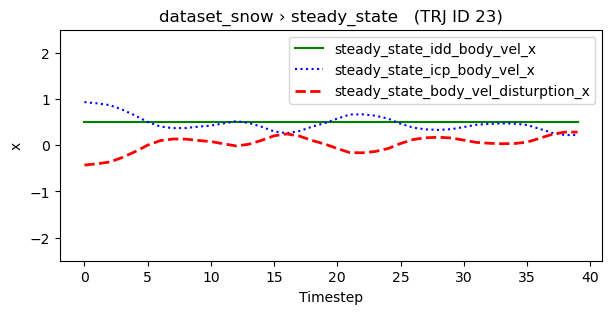

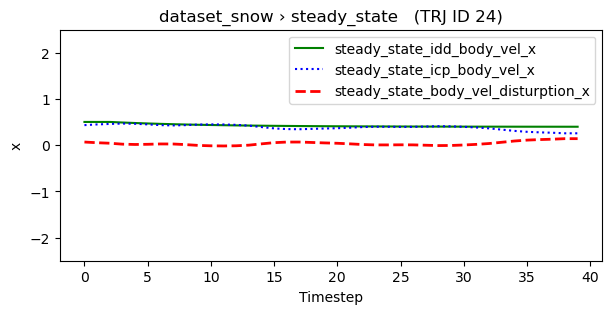

In [87]:
def plot_dataset_trajectory_steady_state_x_array(trajectory_id: int, title: str, y_label:str, ylim: tuple=(-2.5, 2.5)):
    fig = plt.figure(num=None, figsize=(7,3), dpi=None, facecolor=None, edgecolor=None)
    plt.title(f'{title}   (TRJ ID {trajectory_id})')
    plt.plot(mfs.idd_vel.x[trajectory_id, :], label="steady_state_idd_body_vel_x", color="green")
    plt.plot(mfs.icp_vel.x[trajectory_id, :], label="steady_state_icp_body_vel_x", color="blue", linestyle="dotted")
    plt.plot(mfs.body_vel_disturption.x[trajectory_id, :], label="steady_state_body_vel_disturption_x", color="red", linestyle="dashed", linewidth="2.")
    plt.legend()
    plt.ylabel(y_label)
    plt.xlabel('Timestep')
    plt.ylim(*ylim)
    return None

# _ids = [62,29,30,31,32]
_ids = range(23,25)
for _trj_id in _ids:
    plot_dataset_trajectory_steady_state_x_array(trajectory_id=_trj_id, title="dataset_snow › steady_state", y_label="x", ylim=(-2.5, 2.5))

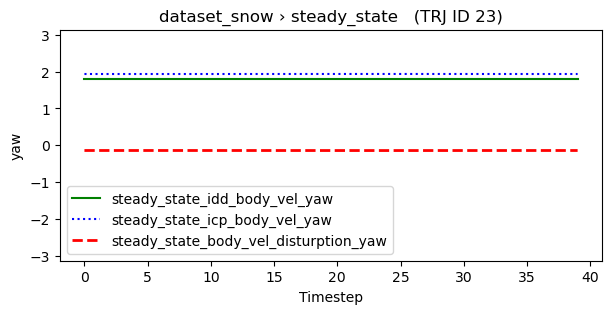

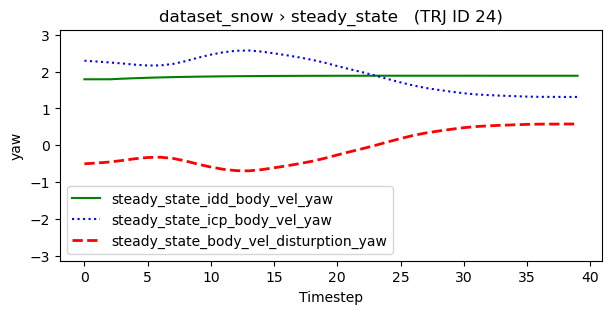

In [88]:
def plot_dataset_trajectory_steady_state_yaw(trajectory_id: int, title: str, y_label:str, ylim: tuple=(-2.5, 2.5)):
    fig = plt.figure(num=None, figsize=(7,3), dpi=None, facecolor=None, edgecolor=None)
    plt.title(f'{title}   (TRJ ID {trajectory_id})')
    plt.plot(mfs.idd_vel.yaw[trajectory_id, :], label="steady_state_idd_body_vel_yaw", color="green")
    plt.plot(mfs.icp_vel.yaw[trajectory_id, :], label="steady_state_icp_body_vel_yaw", color="blue", linestyle="dotted")
    plt.plot(mfs.body_vel_disturption.yaw[trajectory_id, :], label="steady_state_body_vel_disturption_yaw", color="red", linestyle="dashed", linewidth="2.")
    plt.legend()
    plt.ylabel(y_label)
    plt.xlabel('Timestep')
    plt.ylim(*ylim)
    return None

# _ids = [29,30,31,32]
_ids = range(23,25)
for _trj_id in _ids:
    plot_dataset_trajectory_steady_state_yaw(trajectory_id=_trj_id, title="dataset_snow › steady_state", y_label="yaw", ylim=(-3.1416, 3.1416))